# Relative Variance by Layer
Plot mean `rel_var` (or other stats keys) across baselines per layer.

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

In [6]:
# === Configuration ===
experiment_dir = Path("../experiments/features-sample-gemma-3-1b-16k-res-s17")
key = "rel_var"  # any key in stats: rel_var, EV_mu, perp_EV, mean_energy, ...

baseline_groups = {
    "Key": ["query_lens_key_approx", "query_lens_key"],
    "Value": ["query_lens_value_approx", "query_lens_value"],
}

In [7]:
def load_stats_by_layer(jsonl_path: Path, key: str) -> dict[int, list[float]]:
    """Read feature_analysis.jsonl and collect a stats value grouped by layer."""
    layer_values: dict[int, list[float]] = {}
    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                entry = json.loads(line)
            except json.JSONDecodeError:
                continue
            layer = entry.get("layer")
            stats = entry.get("stats") or {}
            val = stats.get(key)
            if layer is None or val is None:
                continue
            layer_values.setdefault(int(layer), []).append(float(val))
    return layer_values

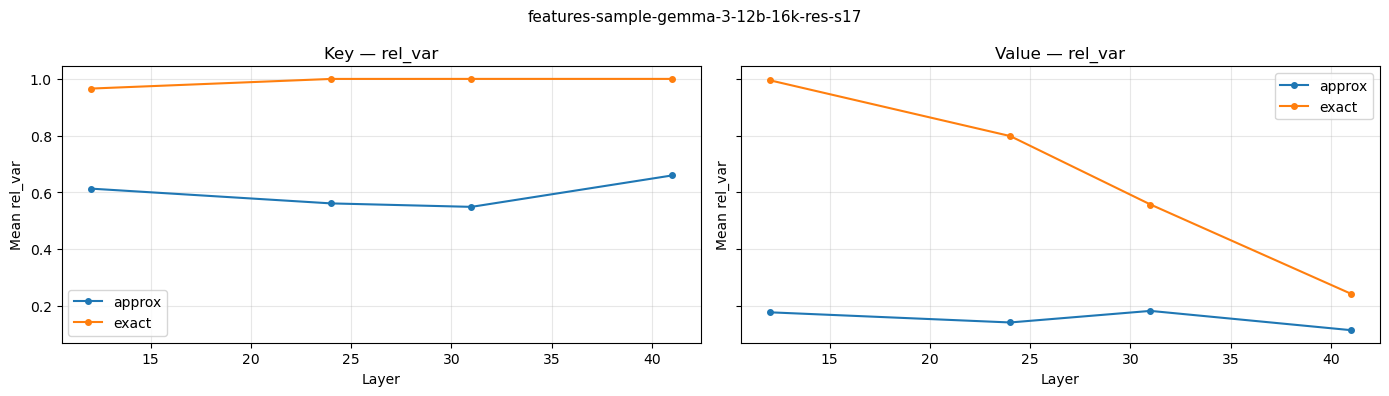

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, (group_name, baselines) in zip(axes, baseline_groups.items()):
    for baseline in baselines:
        jsonl_path = experiment_dir / baseline / "feature_analysis.jsonl"
        if not jsonl_path.exists():
            print(f"Skipping {baseline}: not found")
            continue

        layer_values = load_stats_by_layer(jsonl_path, key)
        if not layer_values:
            print(f"Skipping {baseline}: no {key} data")
            continue

        layers = sorted(layer_values)
        means = [np.mean(layer_values[l]) for l in layers]
        label = "approx" if "approx" in baseline else "full"
        ax.plot(layers, means, marker="o", markersize=4, label=label)

    ax.set_xlabel("Layer")
    ax.set_ylabel(f"Mean {key}")
    ax.set_title(f"{group_name} — {key}")
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle(experiment_dir.name, fontsize=11)
fig.tight_layout()
plt.show()